In [1]:
import os
os.chdir("..")
os.chdir("..")

In [3]:
import minari
import torch
import numpy as np
from minari import DataCollector
from torch.utils.data import DataLoader
from gymnasium import spaces

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['figure.figsize'] = [6, 6]
# plt.figure(figsize=(6,6))

# from ducks.logging.base_logger import logger
from ducks.utils.datat_utils import collate_fn

seed = 42
device = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(seed)
torch.device(device)

device(type='cuda')

In [4]:
def load_minari_dataset(dataset_name = "mujoco/hopper/simple-v0"):
    """load dataset"""
    minari_dataset = minari.load_dataset(dataset_name)
    print("Dataset Name: ", dataset_name)
    print("Observation space:", minari_dataset.observation_space)
    print("Action space:", minari_dataset.action_space)
    print("Total episodes:", minari_dataset.total_episodes)
    print("Total steps:", minari_dataset.total_steps)
    print("\n\n")
    return minari_dataset

def get_filtered_episodes_from_minari_dataset(minari_dataset):
    """sample episodes using iterquartile range based on the rewards"""
    episodes = minari_dataset.sample_episodes(n_episodes=minari_dataset.total_episodes)
    # get id's from the sampled episodes
    rewards = list(map(lambda ep: ep.rewards, episodes))
    rewards = np.concatenate(rewards)

    # get quantiles based on episodes not steps
    # combined rewards from all episodes
    # create quantiles from the combined rewards
    # filter episodes by the average reward for each episode being less than a given quantile
    quantiles = [0.25, 0.5, 0.75]
    reward_quantiles = [np.quantile(rewards, quantile) for quantile in quantiles]
    q1_episodes = minari_dataset.filter_episodes(lambda episode: episode.rewards.mean() < reward_quantiles[0])
    q2_episodes = minari_dataset.filter_episodes(lambda episode: episode.rewards.mean() > reward_quantiles[0] and episode.rewards.mean() < reward_quantiles[1])
    q3_episodes = minari_dataset.filter_episodes(lambda episode: episode.rewards.mean() > reward_quantiles[1] and episode.rewards.mean() < reward_quantiles[2])
    q4_episodes = minari_dataset.filter_episodes(lambda episode: episode.rewards.mean() > reward_quantiles[2])

    filtered_episode_datasets = [q1_episodes, q2_episodes, q3_episodes, q4_episodes]
    return filtered_episode_datasets

def get_rewards_by_episode_quantile(filtered_episode_datasets):
    """pull rewards from each filtered episode dataset and return as a list of arrays
    mostly used for plotting reward distributions by episode quantile
    """
    episode_rewards_by_quantile = []
    for filtered_episode_dataset in filtered_episode_datasets:
        if filtered_episode_dataset.total_episodes: #check that there are episodes in the current quantile
            episode_rewards_by_quantile.append(np.concatenate(list(map(lambda ep: ep.rewards, filtered_episode_dataset))))
    return episode_rewards_by_quantile

def plot_reward_distribution_by_episode_quantile(episode_rewards_by_quantile): 
    """plot reward distribution for each reward quantile"""  
    for i, episode_rewards in enumerate(episode_rewards_by_quantile):
        sns.histplot(episode_rewards, kde=True, alpha=0.5, label=f"Q{i+1} Episode Rewards")
    # Adding labels and legend
    plt.xlabel('Rewards')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

Dataset Name:  mujoco/hopper/simple-v0
Observation space: Box(-inf, inf, (11,), float64)
Action space: Box(-1.0, 1.0, (3,), float32)
Total episodes: 1952
Total steps: 999206





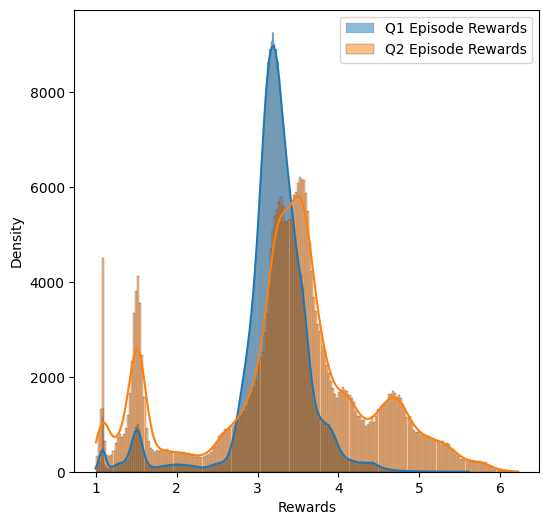

In [5]:
minari_dataset = load_minari_dataset()
filtered_episode_datasets = get_filtered_episodes_from_minari_dataset(minari_dataset) #use these filtered episodes to create dataloaders
episode_rewards_by_quantile = get_rewards_by_episode_quantile(filtered_episode_datasets)
plot_reward_distribution_by_episode_quantile(episode_rewards_by_quantile)

- There is a considerable overlap in reward distribution over Q1 and Q2 episodes.
- This implies that a model trained on data from Q1 episodes will contain pertinent information to be utilized in Q2 episodes.
- Theoretically: use mutual information to construct a proof which shows information related bounds between data distributions of episodes from different quantiles.

In [6]:
def get_dataloader_from_episodes(filtered_episode_datasets):
    """
    Get dataloaders from filtered episode datasets
    returns: list of dataloaders. Each dataloader contains episodes for a given quantile.
    """
    dataloaders = []
    for filtered_episode_dataset in filtered_episode_datasets:
        if filtered_episode_dataset.total_episodes:
            dataloaders.append(
                DataLoader(
                    filtered_episode_dataset, 
                    batch_size=32, 
                    shuffle=True, 
                    collate_fn=collate_fn,
                    num_workers=1
                )
            )
    return dataloaders

# env = minari_dataset.recover_environment()
# observation_space = env.observation_space
# action_space = env.action_space
# assert isinstance(observation_space, spaces.Box)
# assert isinstance(action_space, spaces.Box)
dataloaders = get_dataloader_from_episodes(filtered_episode_datasets)
sample_from_batch = next(iter(dataloaders[0]))

def plot_dist_from_sample(sample):
    sns.displot(sample.cpu().numpy(), kind="hist", height=2, aspect=1.5)
    plt.show()

### Forward Pass

In [6]:
import torch.nn.functional as F

def linear_beta_schedule(timesteps, start=0.0002, end=0.02):
    return torch.linspace(start, end, timesteps)

def get_index_from_list(vals, t, x_shape):
    batch_size = t.shape[0]
    out = vals.gather(-1, t.cpu())
    return out.reshape(batch_size, *((1,)*(len(x_shape)-1))).to(t.device)

def forward_diffusion_sample(x_0, t, device="cuda"):
    noise=torch.randn_like(x_0)
    sqrt_alphas_cumprod_t = get_index_from_list(sqrt_alphas_cumprod, t, x_0.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(
        sqrt_one_minus_alphas_cumprod, t, x_0.shape
    )
    return sqrt_alphas_cumprod_t.to(device)*x_0.to(device)\
        + sqrt_one_minus_alphas_cumprod_t.to(device)*noise.to(device), noise.to(device)
        
## define beta schedule
T = 300 #time steps
betas = linear_beta_schedule(timesteps=T)

# pre-compute terms for closed form solution
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1,0), value=1.0)
sqrt_recip_alphas = torch.sqrt(1.0/alphas) #reciprocal alphas
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod) #this is used up in the forward_diffusion_sample function
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)
posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

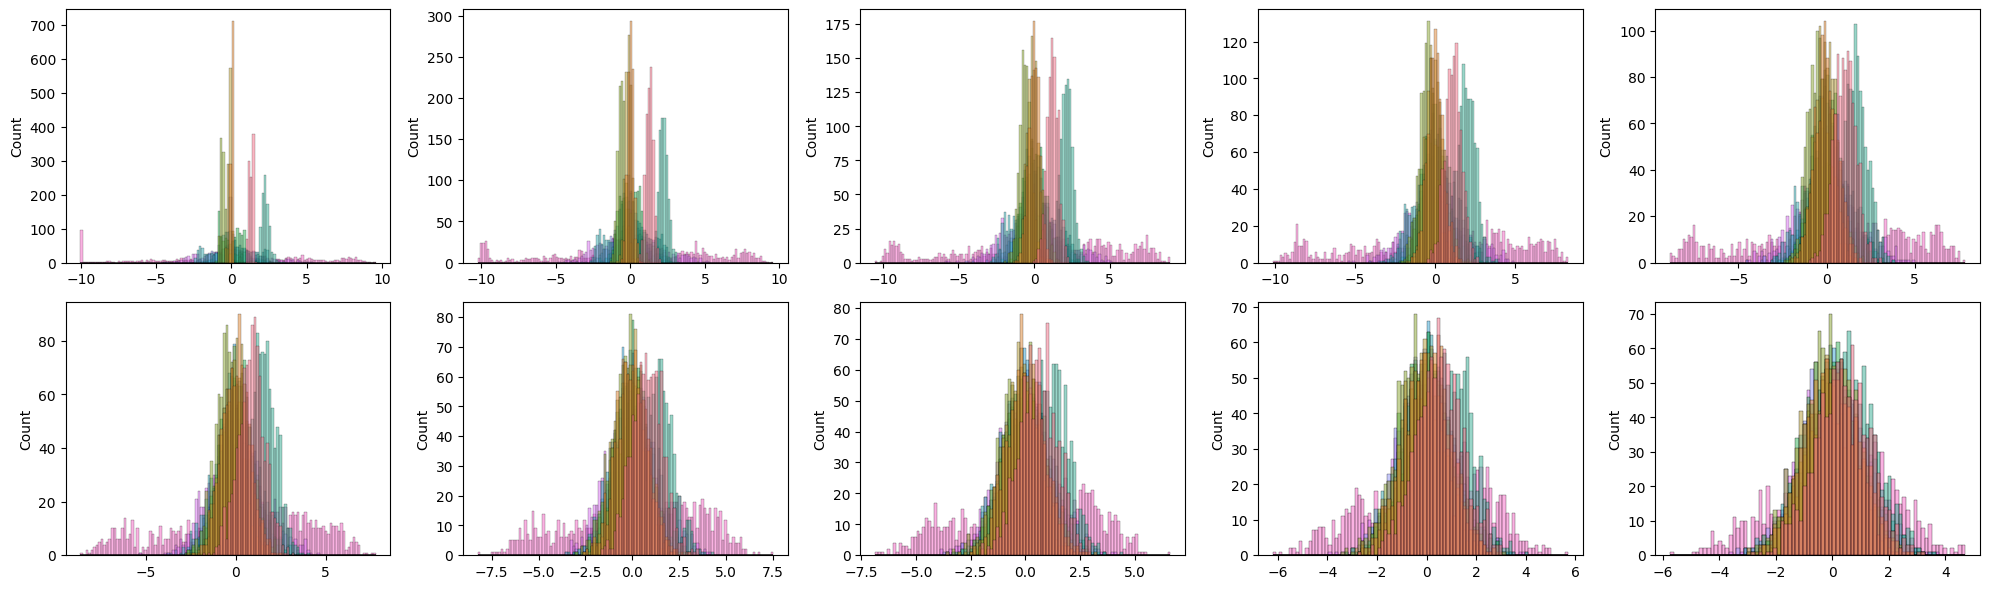

In [18]:
# idea 1: combine observations actions rewards into a single array and then train a diffusion model to generate all 3 at once
# idea 2: train a diffusion model to generate observations actions and rewards as a multi output head
num_plots = 10
stepsize = int(T/num_plots)

fig, axs = plt.subplots(2, len(range(0, T, stepsize))//2, figsize=(20,6))
axs = axs.flatten()
for idx, ax in zip(range(0, T, stepsize), axs):
    t = torch.Tensor([idx]).type(torch.int64)
    sample, noise = forward_diffusion_sample(sample_from_batch['observations'][0], t)
    # axs = plt.subplot(1, num_plots+1, int(idx/stepsize)+1)
    sns.histplot(sample.cpu().numpy(), kde=False, ax=ax, legend=False)
plt.tight_layout()
plt.show()
# len(axs)

- every episode interaction yields new information for the agent
- the new information comes in the form of observations and rewards
- as the agent interacts and learns from the environment the rewards go up
- this way the agent learns which observations/states are high reward yielding states
- if the agent is trained from episodic data then a learning agents rewards reflect an upward trajectory
- if epsisodic data is temporally (time) sliced and a diffusion model is trained for each slice then the diffusion model trained on a given slice would
show the environment's state and reward dynamics for the given slice.
- idea: for each time slice train a separate diffusion model -> interpolate the current diffusion model with parameters from the previously trained diffusion model -> generate a batch from this diffusion model -> train the agent on this sample (idea here is that the previous diffusion model contains information which is still relevant for the agent - continual learning?)
- repeat the step above until satisfied.